<a href="https://colab.research.google.com/github/Tharun-2/AIML/blob/main/Object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import tensorflow as tf
from keras.utils import np_utils
from matplotlib import pyplot as plt
import numpy as np

In [13]:
import keras

In [14]:
(x_train,y_train),(x_test,y_test)= tf.keras.datasets.cifar10.load_data()

In [15]:
print ('Training Images:{}'.format(x_train.shape))
print('TestingImages{}'.format(x_test.shape))

Training Images:(50000, 32, 32, 3)
TestingImages(10000, 32, 32, 3)


In [16]:
print (x_train[0].shape)

(32, 32, 3)


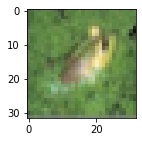

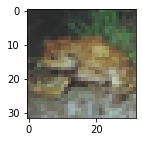

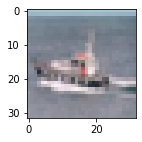

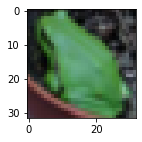

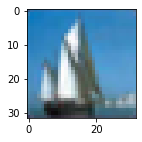

In [17]:
for i in range(242,247):
    plt.subplots(figsize=(2,2))
    img=x_train[i]
    plt.imshow(img)
    plt.show()

In [18]:
x_train = x_train.reshape(x_train.shape[0], 32, 32, 3)
x_test = x_test.reshape(x_test.shape[0], 32, 32, 3)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train /= 255
x_test/255

n_classes = 10


print("Shape before one-hot encoding:", y_train.shape)
y_train = np_utils.to_categorical(y_train, n_classes)
y_test = np_utils.to_categorical(y_test, n_classes)
print("Shape after one-hot encoding:", y_train.shape)

Shape before one-hot encoding: (50000, 1)
Shape after one-hot encoding: (50000, 10)


In [ ]:
from keras.layers.pooling import MaxPooling2D
from keras.models import Sequential 
from keras.layers import Dense,Dropout,MaxPool2D,Flatten,Conv2D


model=Sequential()
#convolutional layers
model.add(Conv2D(50,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu',input_shape=(32,32, 3)))

model.add(Conv2D(75,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(125,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(175,kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

#hidden layer
model.add(Dense(500,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(250,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(125,activation='relu'))
model.add(Dropout(0.2))
#output layer
model.add(Dense(10,activation='softmax'))

#compiling
model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='adam')

#training  the model
model.fit(x_train,y_train,batch_size=128,epochs=7,validation_data=(x_test,y_test))


In [ ]:
classes = range(0,10)
 names=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
 class_labels = dict(zip(classes,names))

 batch = x_test[100:109]
 labels=np.argmax(y_test[100:109],axis=-1)
 #making predictions
 predictions=model.predict(batch,verbose=1)

In [ ]:
print(predictions)